Actual Values: [55 85 75]
Predicted Values: [55.         84.34210526 75.        ]
MSE: 0.14427516158818296
R2: 0.9990725168183617

Formatted Dataset:

 ID Student  Hours_Studied  Attendance_Percent  Assignment_Score  Internal_Score  Final_Score Status
  1       A              2                  60                50              40           45   Pass
  2       B              3                  65                55              45           50   Pass
  3       C              4                  70                60              50           55   Pass
  4       D              5                  75                65              55           60   Pass
  5       E              6                  80                70              60           65   Pass
  6       F              7                  85                75              65           70   Pass
  7       G              8                  90                80              70           75   Pass
  8       H              1               

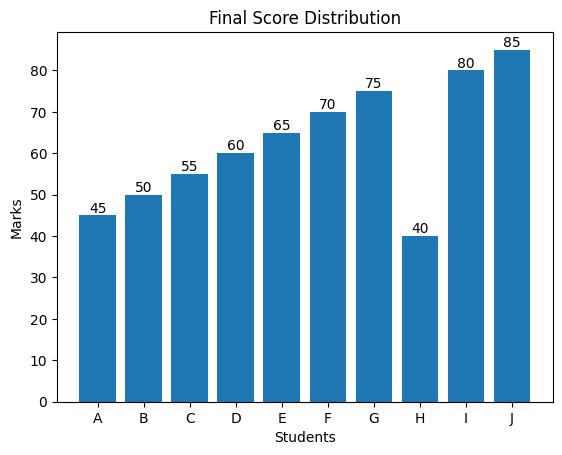

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split as split_data
from sklearn.linear_model import LinearRegression as LR
from sklearn.metrics import mean_squared_error as mse_calc, r2_score as r2_calc
import matplotlib.pyplot as plt

# -------------------- Create Sample Dataset --------------------
student_info = {
    "Student": list("ABCDEFGHIJ"),
    "Hours_Studied": [2,3,4,5,6,7,8,1,9,10],
    "Attendance_Percent": [60,65,70,75,80,85,90,55,95,98],
    "Assignment_Score": [50,55,60,65,70,75,80,45,85,90],
    "Internal_Score": [40,45,50,55,60,65,70,35,75,80],
    "Final_Score": [45,50,55,60,65,70,75,40,80,85]
}

df_students = pd.DataFrame(student_info)

# Add unique ID column
df_students["ID"] = np.arange(1, len(df_students) + 1)
df_students = df_students.set_index("ID")

# -------------------- Feature Selection --------------------
features = df_students[["Hours_Studied", "Attendance_Percent", 
                        "Assignment_Score", "Internal_Score"]]
target = df_students["Final_Score"]

# -------------------- Train-Test Split --------------------
X_tr, X_te, y_tr, y_te = split_data(features, target, 
                                   test_size=0.25, random_state=1)

# -------------------- Model Training --------------------
regressor = LR()
regressor.fit(X_tr, y_tr)

# -------------------- Prediction --------------------
predicted_values = regressor.predict(X_te)

print("Actual Values:", y_te.values)
print("Predicted Values:", predicted_values)

# -------------------- Model Evaluation --------------------
error = mse_calc(y_te, predicted_values)
accuracy = r2_calc(y_te, predicted_values)

print("MSE:", error)
print("R2:", accuracy)

# -------------------- Result Classification --------------------
def get_result(score):
    return "Pass" if score >= 40 else "Fail"

df_students["Status"] = df_students["Final_Score"].apply(get_result)

# Reset index for display
df_students = df_students.reset_index()

# Reorder columns
final_df = df_students[["ID", "Student", "Hours_Studied", 
                        "Attendance_Percent", "Assignment_Score", 
                        "Internal_Score", "Final_Score", "Status"]]

print("\nFormatted Dataset:\n")
print(final_df.to_string(index=False))

# -------------------- Visualization --------------------
plt.figure()

bars = plt.bar(final_df["Student"], final_df["Final_Score"])

plt.title("Final Score Distribution")
plt.xlabel("Students")
plt.ylabel("Marks")

# Annotate bars
for b in bars:
    height = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, height,
             f"{int(height)}", ha='center', va='bottom')

plt.show()